# Monte Carlo Option Pricer — Fase 1: opzioni europee

Prezziamo call e put europee simulando il prezzo del sottostante con una **Geometric Brownian Motion** sotto la misura **risk-neutral** $\mathbb{Q}$:

$$S_T = S_0 \exp\left[\left(r - \tfrac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}\,Z\right], \qquad Z \sim \mathcal{N}(0,1)$$

$$\text{Prezzo} = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}\big[\text{payoff}(S_T)\big] \approx e^{-rT}\,\frac{1}{N}\sum_{i=1}^{N} \text{payoff}\big(S_T^{(i)}\big)$$

**Architettura del package `option_pricer`**

| Modulo | Responsabilità | Contenuto |
|---|---|---|
| `models.py` | *come* si muove il sottostante | `GBM` |
| `instruments.py` | *cosa* paga il contratto | `EuropeanCall`, `EuropeanPut` |
| `monte_carlo.py` | *come* si calcola il prezzo | `price_monte_carlo`, `MCResult` |

## 0. Setup

In [1]:
# Rende importabile il package option_pricer, sia su Colab sia in locale
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/FedeDiCandia/monte-carlo-option-pricer.git"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Su Colab il progetto non c'è: lo scarica da GitHub, una volta per sessione
    PROJECT_DIR = Path("/content/monte-carlo-option-pricer")
    if not PROJECT_DIR.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(PROJECT_DIR)], check=True)
else:
    # In locale il notebook sta in notebooks/, il package nella cartella superiore
    PROJECT_DIR = Path.cwd().parent

# Controllo esplicito: senza, un percorso sbagliato farebbe fallire gli import della cella dopo con un errore poco chiaro
if not (PROJECT_DIR / "option_pricer" / "plotting.py").is_file():
    raise FileNotFoundError(
        f"Package option_pricer non trovato in {PROJECT_DIR}. "
        "Su Colab: Runtime → Disconnetti ed elimina runtime, poi esegui di nuovo tutto. "
        "In locale: apri il notebook dalla cartella notebooks/ del progetto."
    )

sys.path.insert(0, str(PROJECT_DIR))
print("Package option_pricer pronto.")

Package option_pricer pronto.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import lognorm, norm

from option_pricer import GBM, EuropeanCall, EuropeanPut, discounted_payoffs, price_monte_carlo
from option_pricer.plotting import BLACK, FILL, LIGHT, MID, add_caption, apply_style, math_int

# Stile grafico accademico comune a tutti i notebook: font serif, riquadro con tacche interne, scala di grigi
apply_style()

## 1. Parametri

Tre gruppi, che corrispondono ai tre strati dell'architettura: **mercato** (modello), **contratto** (strumento), **numerici** (motore).

In [3]:
# --- Mercato (modello) ---
S0 = 100.0      # prezzo spot del sottostante oggi
r = 0.05        # tasso risk-free annuo, capitalizzazione continua
sigma = 0.20    # volatilità annua

# --- Contratto (strumento) ---
K = 100.0       # strike: qui K = S0, opzione "at-the-money"
T = 1.0         # scadenza in anni

# --- Numerici (motore) ---
N = 200_000     # numero di traiettorie simulate
SEED = 42       # seme casuale: stessi numeri a ogni esecuzione

model = GBM(S0=S0, r=r, sigma=sigma)
call = EuropeanCall(K=K, T=T)
put = EuropeanPut(K=K, T=T)

## 2. Pricing

In [4]:
call_result = price_monte_carlo(model, call, n_paths=N, seed=SEED)
put_result = price_monte_carlo(model, put, n_paths=N, seed=SEED)

print("Call:", call_result)
print("Put: ", put_result)

Call: 10.4634 ± 0.0331 (SE)  |  IC 95%: [10.3985, 10.5283]  |  N = 200,000
Put:  5.5889 ± 0.0194 (SE)  |  IC 95%: [5.5509, 5.6269]  |  N = 200,000


## 3. Verifica del drift: perché serve $-\tfrac{1}{2}\sigma^2$

Sotto $\mathbb{Q}$ il sottostante deve rendere in media quanto il risk-free: $\mathbb{E}^{\mathbb{Q}}[S_T] = S_0 e^{rT}$.
Confrontiamo la simulazione corretta con una che usa (erroneamente) drift $r$ nel log-prezzo.

In [5]:
# Simulazione corretta, tramite il modello
S_T = model.simulate_paths(T=T, n_steps=1, n_paths=N, rng=np.random.default_rng(SEED))[:, -1]

# Simulazione SBAGLIATA: stessi shock Z, ma senza correzione di Itô nell'esponente
Z = np.random.default_rng(SEED).standard_normal(N)
S_T_wrong = S0 * np.exp(r * T + sigma * np.sqrt(T) * Z)

print(f"Teorico            S0·e^(rT)          = {S0 * np.exp(r * T):8.3f}")
print(f"Drift r - σ²/2  -> media simulata      = {S_T.mean():8.3f} ± {S_T.std(ddof=1) / np.sqrt(N):.3f}")
print(f"Drift r         -> media simulata      = {S_T_wrong.mean():8.3f}   (≈ S0·e^((r+σ²/2)T) = {S0 * np.exp((r + 0.5 * sigma**2) * T):.3f})")

Teorico            S0·e^(rT)          =  105.127
Drift r - σ²/2  -> media simulata      =  105.124 ± 0.048
Drift r         -> media simulata      =  107.248   (≈ S0·e^((r+σ²/2)T) = 107.251)


## 4. Come appaiono le traiettorie

Simuliamo 20.000 traiettorie con 252 passi (i giorni di borsa in un anno) e mostriamo le **bande di percentili**: la fascia più scura contiene il 50% centrale degli scenari, quella più chiara il 90%. Cinque traiettorie di esempio mostrano quanto è irregolare un singolo percorso.

Le bande si allargano col tempo (la deviazione standard del log-prezzo cresce come $\sigma\sqrt{t}$) e sono asimmetriche verso l'alto, perché la distribuzione è lognormale. Per lo stesso motivo la **media** $S_0 e^{rt}$ sta sopra la **mediana** $S_0 e^{(r-\sigma^2/2)t}$: pochi scenari molto alti tirano su la media. È la correzione di Itô vista al punto 3.

Per *prezzare* un'europea basta invece **un** passo: lo schema è esatto e il payoff dipende solo da $S_T$.

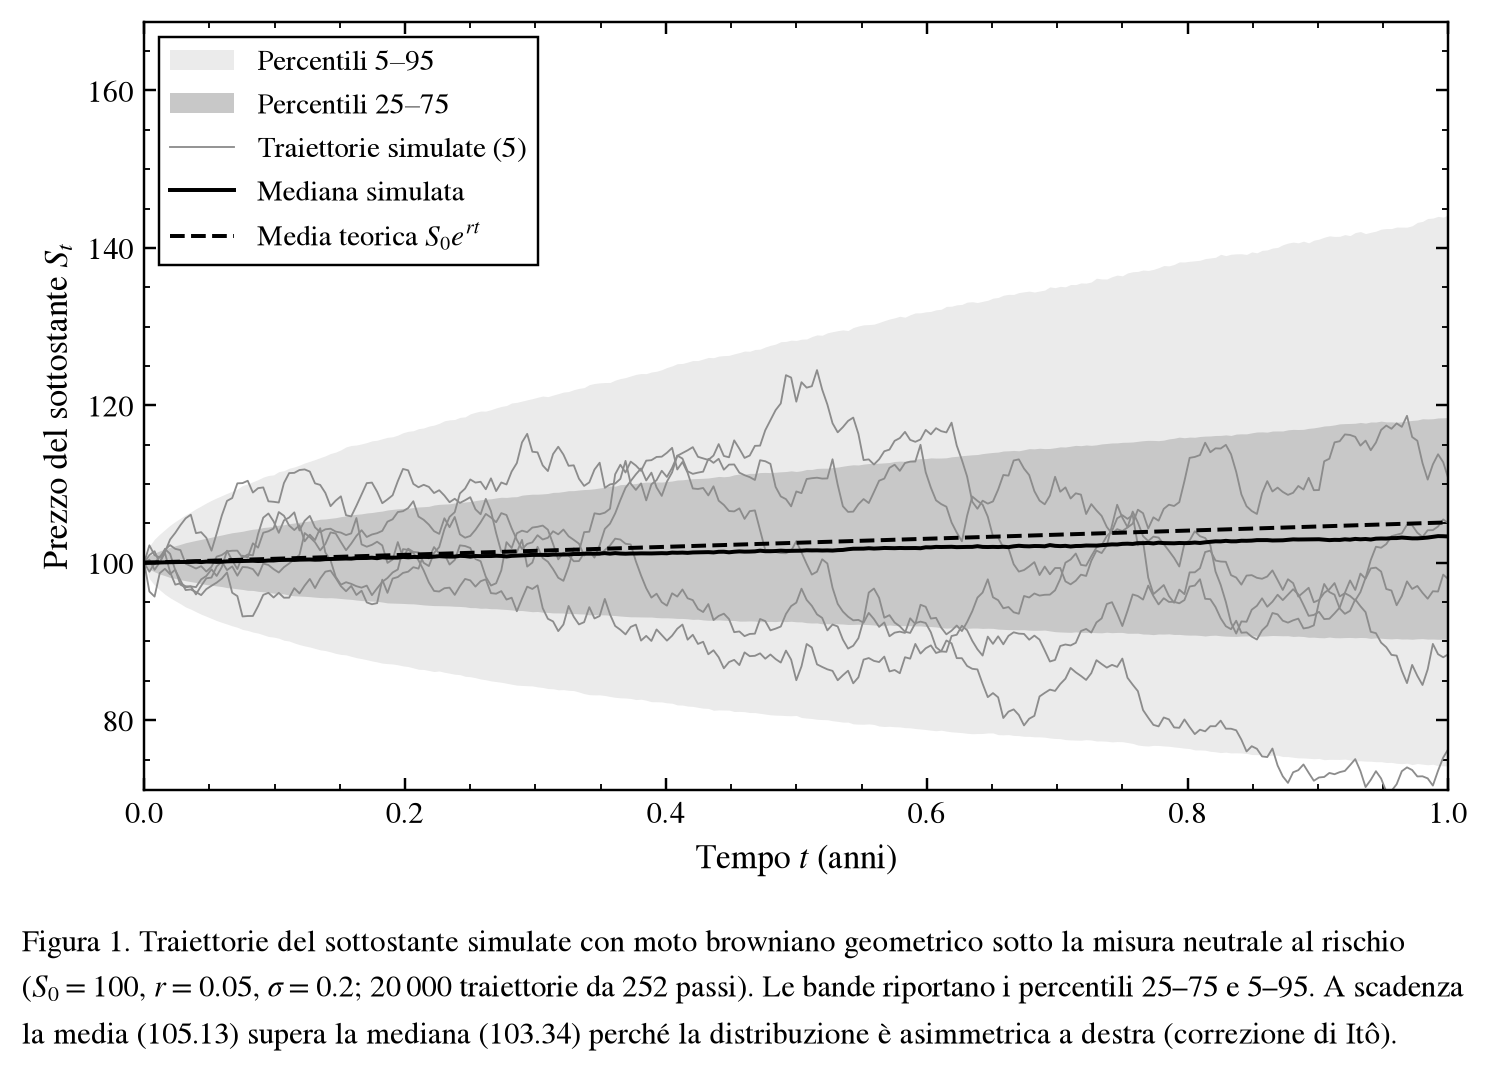

In [6]:
n_fan, n_steps_show = 20_000, 252
paths_show = model.simulate_paths(T=T, n_steps=n_steps_show, n_paths=n_fan, rng=np.random.default_rng(SEED))
t = np.linspace(0, T, n_steps_show + 1)  # griglia temporale: 253 istanti da 0 a T

# Percentili istante per istante: axis=0 li calcola su tutte le traiettorie, colonna per colonna
p5, p25, p50, p75, p95 = np.percentile(paths_show, [5, 25, 50, 75, 95], axis=0)
mean_theory = S0 * np.exp(r * t)

fig, ax = plt.subplots()
ax.fill_between(t, p5, p95, color=FILL, linewidth=0, label="Percentili 5–95")
ax.fill_between(t, p25, p75, color=LIGHT, linewidth=0, label="Percentili 25–75")
sample_lines = ax.plot(t, paths_show[:5].T, color=MID, linewidth=0.6)  # 5 traiettorie di esempio
sample_lines[0].set_label("Traiettorie simulate (5)")
ax.plot(t, p50, color=BLACK, linewidth=1.3, label="Mediana simulata")
ax.plot(t, mean_theory, color=BLACK, linewidth=1.3, linestyle="--", label=r"Media teorica $S_0e^{rt}$")

ax.set_xlim(0, T)
ax.set_ylim(p5.min() - 3, p95.max() + 0.35 * (p95.max() - p5.min()))  # spazio in alto per la legenda
ax.set(xlabel=r"Tempo $t$ (anni)", ylabel=r"Prezzo del sottostante $S_t$")
ax.legend(loc="upper left")
fig.tight_layout()
add_caption(fig, 1,
    rf"Traiettorie del sottostante simulate con moto browniano geometrico sotto la misura neutrale al rischio "
    rf"($S_0={S0:g}$, $r={r:g}$, $\sigma={sigma:g}$; {math_int(n_fan)} traiettorie da {n_steps_show} passi). "
    rf"Le bande riportano i percentili 25–75 e 5–95. A scadenza la media ({mean_theory[-1]:.2f}) supera la "
    rf"mediana ({p50[-1]:.2f}) perché la distribuzione è asimmetrica a destra (correzione di Itô).")
plt.show()

## 5. Distribuzione di $S_T$: lognormale

Se $\ln S_T$ è normale, $S_T$ è **lognormale**: sempre positivo, asimmetrico a destra. L'istogramma simulato deve coincidere con la densità teorica. La parte scura è dove la call finisce *in the money* ($S_T > K$).

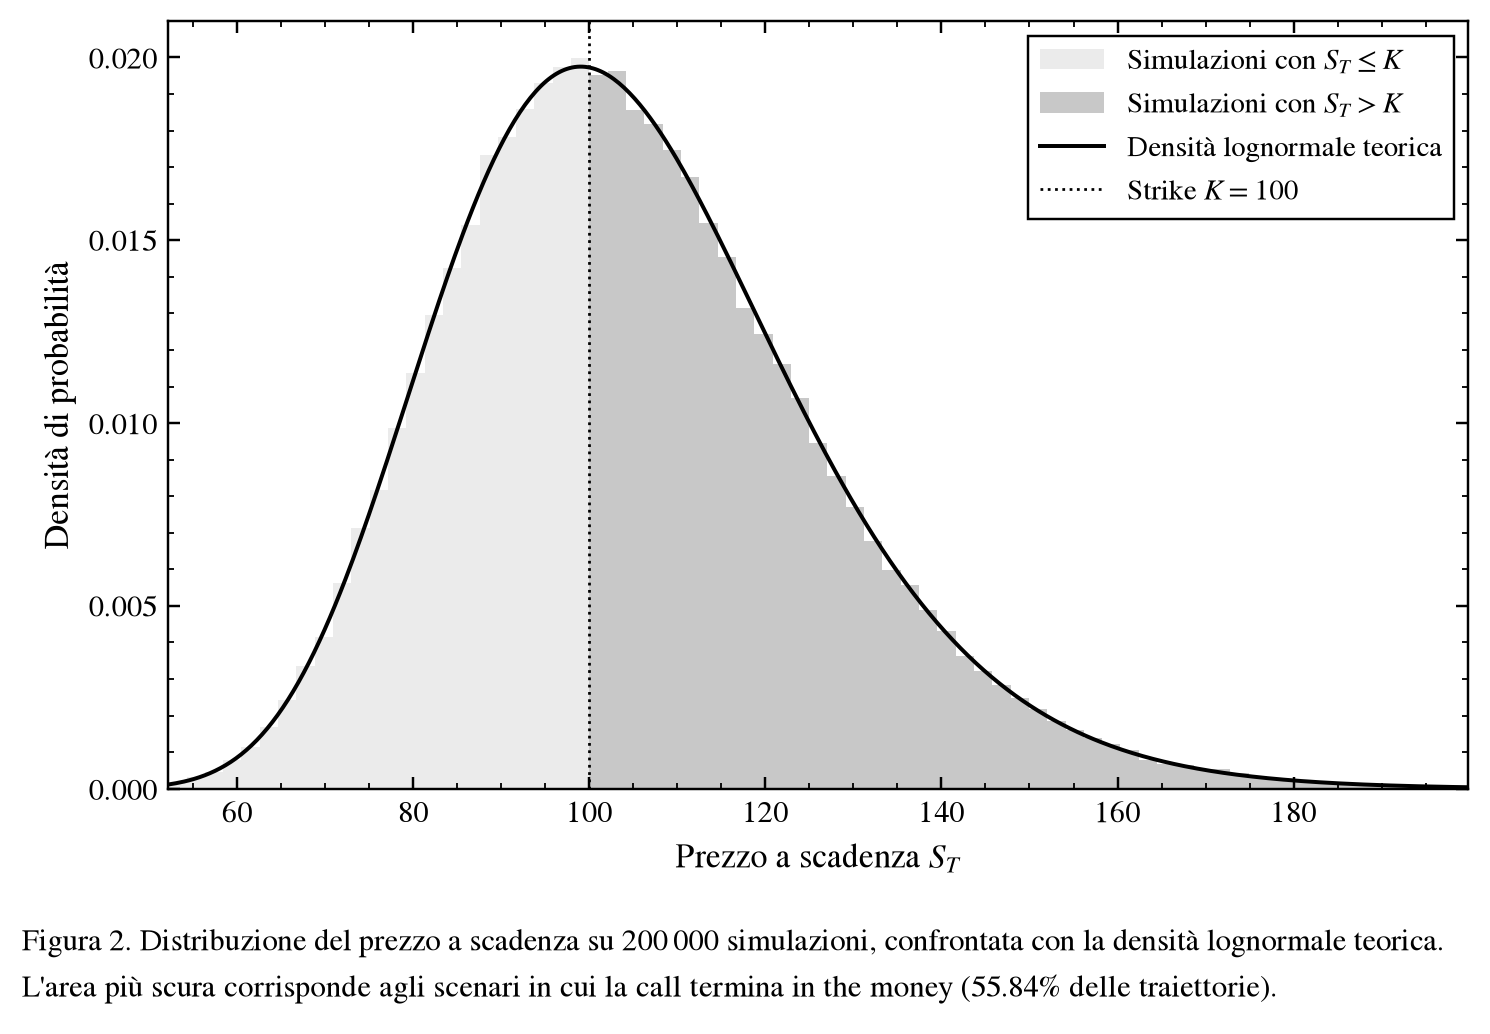

Probabilità (sotto Q) che la call finisca in the money: 55.84%


In [7]:
# ln S_T ~ N(m, s²)  con  m = ln S0 + (r - σ²/2)T,  s = σ√T
s = sigma * np.sqrt(T)
theoretical = lognorm(s=s, scale=S0 * np.exp((r - 0.5 * sigma**2) * T))  # scipy: scale = e^m

# Barre larghe `bin_width`, con K esattamente su un bordo: così le barre si dividono proprio allo strike
x_low, x_high = theoretical.ppf(0.0005), theoretical.ppf(0.9995)
bin_width = (x_high - x_low) / 70
bins = K + bin_width * np.arange(np.floor((x_low - K) / bin_width), np.ceil((x_high - K) / bin_width) + 1)
weights = np.full(N, 1 / (N * bin_width))  # densità normalizzata su TUTTE le N traiettorie, anche fuori dal grafico
itm = S_T > K                              # scenari in cui la call finisce in the money
x = np.linspace(bins[0], bins[-1], 500)

fig, ax = plt.subplots()
ax.hist(S_T[~itm], bins=bins, weights=weights[~itm], histtype="stepfilled", color=FILL, label=r"Simulazioni con $S_T\leq K$")
ax.hist(S_T[itm], bins=bins, weights=weights[itm], histtype="stepfilled", color=LIGHT, label=r"Simulazioni con $S_T>K$")
ax.plot(x, theoretical.pdf(x), color=BLACK, linewidth=1.3, label="Densità lognormale teorica")
ax.axvline(K, color=BLACK, linewidth=0.9, linestyle=":", label=rf"Strike $K={K:g}$")

ax.set_xlim(bins[0], bins[-1])
ax.set_ylim(bottom=0)
ax.yaxis.set_major_locator(MaxNLocator(5))  # tacche ogni 0.005: meno decimali sull'asse
ax.set(xlabel=r"Prezzo a scadenza $S_T$", ylabel="Densità di probabilità")
ax.legend(loc="upper right")
fig.tight_layout()
add_caption(fig, 2,
    f"Distribuzione del prezzo a scadenza su {math_int(N)} simulazioni, confrontata con la densità lognormale "
    f"teorica. L'area più scura corrisponde agli scenari in cui la call termina in the money "
    f"({itm.mean():.2%} delle traiettorie).")
plt.show()

print(f"Probabilità (sotto Q) che la call finisca in the money: {itm.mean():.2%}")

## 6. Convergenza e errore standard

Simuliamo una volta sola e guardiamo la stima usando solo i primi $n$ scenari, per $n$ crescente.
Per il Teorema del Limite Centrale l'errore standard è $\text{SE} = s/\sqrt{n}$: per dimezzarlo servono **4 volte** le traiettorie.

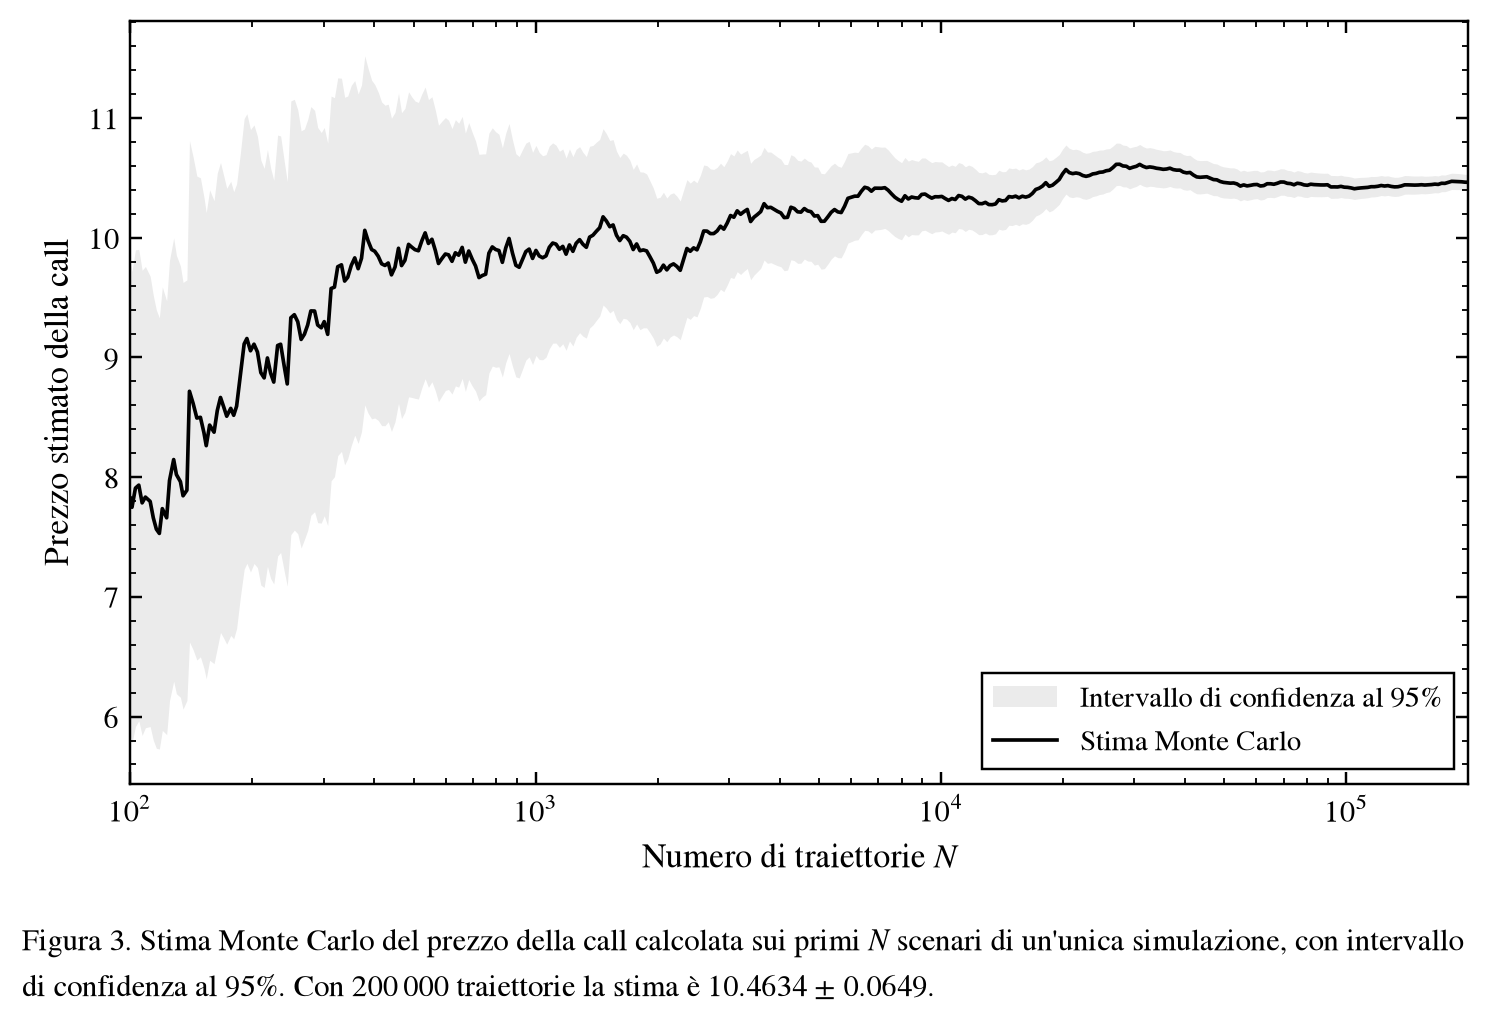

In [8]:
X = discounted_payoffs(model, call, n_paths=N, seed=SEED)  # payoff scontati, uno per scenario
n = np.arange(1, N + 1)

# Media e varianza "in corsa" con somme cumulate (evita di rifare N simulazioni)
running_mean = np.cumsum(X) / n
running_var = (np.cumsum(X**2) - n * running_mean**2) / np.maximum(n - 1, 1)
running_se = np.sqrt(np.maximum(running_var, 0.0) / n)

# Punti spaziati in scala log da n = 100 a N (le primissime stime sono solo rumore)
idx = np.unique(np.geomspace(100, N, 400).astype(int)) - 1
z = norm.ppf(0.975)  # ≈ 1.96
ci_low, ci_high = running_mean - z * running_se, running_mean + z * running_se

fig, ax = plt.subplots()
ax.fill_between(n[idx], ci_low[idx], ci_high[idx], color=FILL, linewidth=0, label="Intervallo di confidenza al 95%")
ax.plot(n[idx], running_mean[idx], color=BLACK, linewidth=1.2, label="Stima Monte Carlo")
ax.set_xscale("log")
ax.set_xlim(n[idx[0]], N)
ax.set(xlabel=r"Numero di traiettorie $N$", ylabel="Prezzo stimato della call")
ax.legend(loc="lower right")
fig.tight_layout()
add_caption(fig, 3,
    f"Stima Monte Carlo del prezzo della call calcolata sui primi $N$ scenari di un'unica simulazione, con "
    f"intervallo di confidenza al 95%. Con {math_int(N)} traiettorie la stima è "
    f"{running_mean[-1]:.4f} ± {z * running_se[-1]:.4f}.")
plt.show()

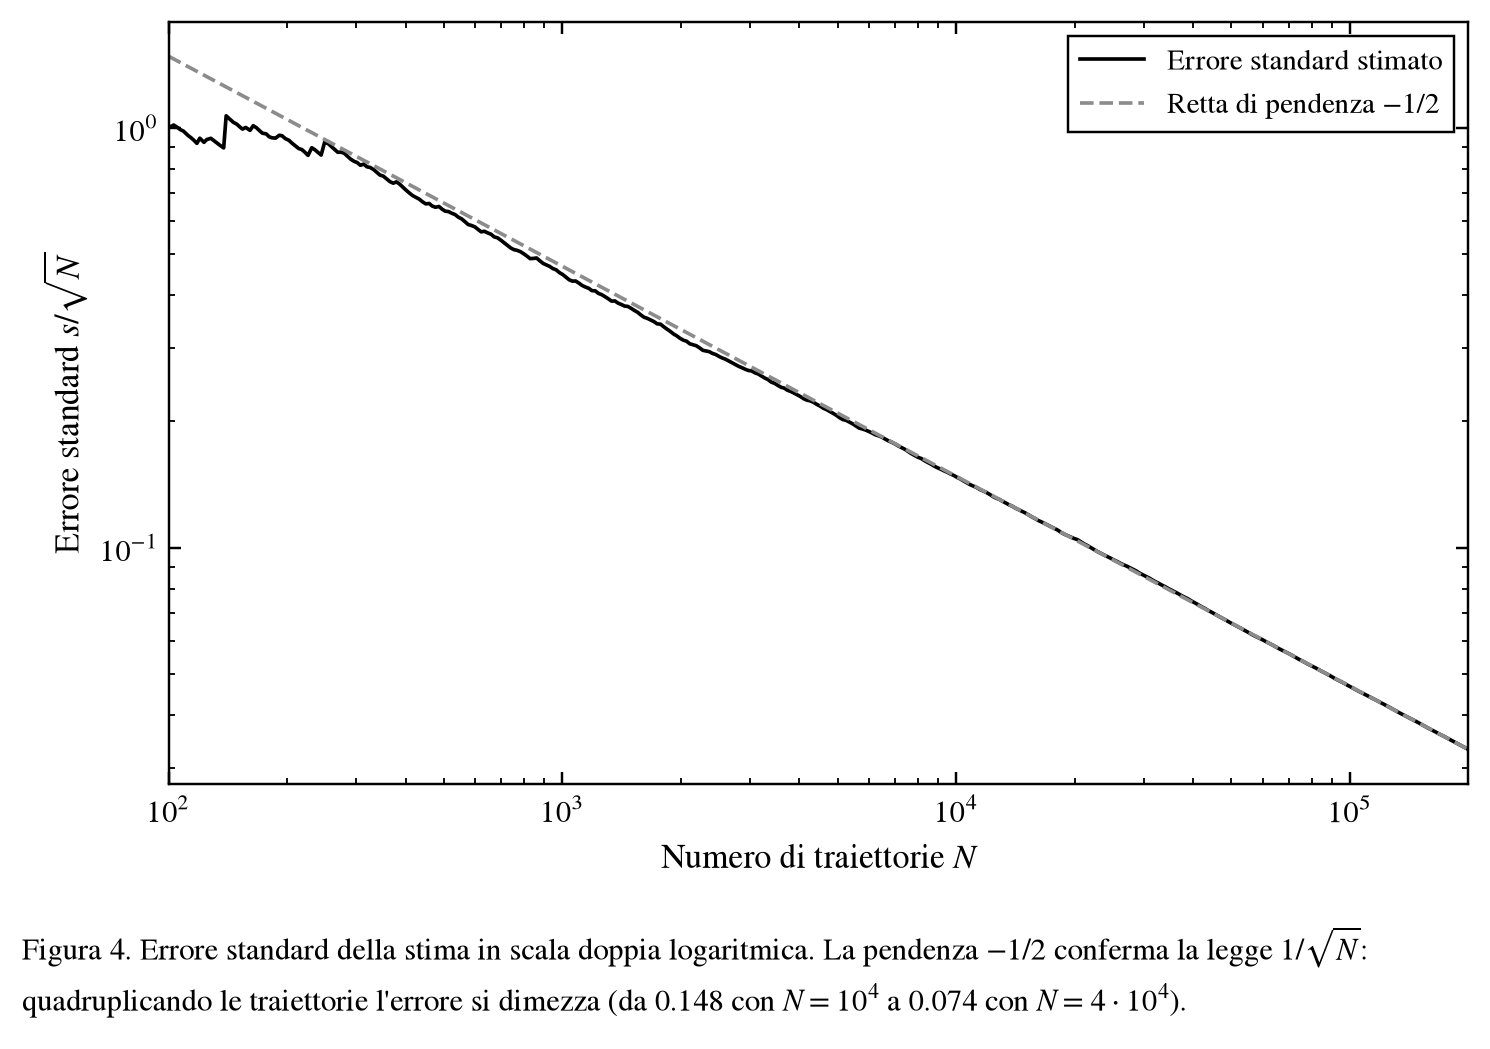

In [9]:
# Retta di riferimento con pendenza -1/2 in scala log-log, passante per l'ultimo punto
se_reference = running_se[-1] * np.sqrt(N / n[idx])
se_a, se_b = running_se[-1] * np.sqrt(N / 10_000), running_se[-1] * np.sqrt(N / 40_000)

fig, ax = plt.subplots()
ax.loglog(n[idx], running_se[idx], color=BLACK, linewidth=1.2, label="Errore standard stimato")
ax.loglog(n[idx], se_reference, color=MID, linewidth=1.2, linestyle="--", label=r"Retta di pendenza $-1/2$")
ax.set_xlim(n[idx[0]], N)
ax.set(xlabel=r"Numero di traiettorie $N$", ylabel=r"Errore standard $s/\sqrt{N}$")
ax.legend(loc="upper right")
fig.tight_layout()
add_caption(fig, 4,
    rf"Errore standard della stima in scala doppia logaritmica. La pendenza $-1/2$ conferma la legge "
    rf"$1/\sqrt{{N}}$: quadruplicando le traiettorie l'errore si dimezza (da {se_a:.3f} con $N=10^4$ "
    rf"a {se_b:.3f} con $N=4\cdot10^4$).")
plt.show()

## Riepilogo

- **Modello**: GBM con drift risk-neutral $r - \tfrac{1}{2}\sigma^2$ nel log-prezzo → $\mathbb{E}^{\mathbb{Q}}[S_T] = S_0 e^{rT}$ (verificato al punto 3).
- **Prezzo**: media dei payoff scontati con $e^{-rT}$.
- **Incertezza**: $\text{SE} = s/\sqrt{N}$, intervallo di confidenza al 95% = prezzo $\pm 1.96\,\text{SE}$.
- **Numerica**: per un'europea sotto GBM basta un solo passo temporale, perché la soluzione è esatta.